## XOR


| X1    | X2       | Out  |
| :-----: |:--------:| :----:|
|   0   |    0     |   0  |
|   0   |    1     |   1  |
|   1   |    0     |   1  |
|   1   |    1     |   0  |



In [78]:
import numpy as np

In [77]:
input_features = np.array([[0,0], [0,1], [1,0], [1,1]])
target_output = np.array([[0,1,1,0]])
target_output = target_output.reshape(4,1)

## Perceptron

In [79]:
weights = np.array([[0.1], [0.2]])
bias = 0.3
lr = 0.01

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):  # we need the derivative in GD
    return sigmoid(x) * (1 - sigmoid(x))

for epoch in range(50000):
    
    inputs = input_features                  
    in_o = np.dot(inputs, weights) + bias    #feed-forward input
    out_o = sigmoid(in_o)           # feed-forward output        
    error = out_o - target_output   # back-propogation 
    
    x = error.sum()
    
    if epoch % 1000 == 0:
        print(f'epoch {epoch}. Error {x}')

    derr_dout = error                     # 1st deriv
    dout_din = sigmoid_derivative(out_o)  # 2nd deriv

    deriv = derr_dout * dout_din 
    
    inputs = input_features.T           # 3rd deriv
    
    deriv_final = np.dot(inputs,deriv)  # that's the one we were looking for

    weights -= lr * deriv_final    # update weights 
    for i in deriv:
        bias -= lr * i             # update bias

epoch 0. Error 0.441245814351761
epoch 1000. Error 0.012968341182077792
epoch 2000. Error 0.0014554728665179817
epoch 3000. Error 0.0008567365564094986
epoch 4000. Error 0.0006128457699500767
epoch 5000. Error 0.00044187489655800327
epoch 6000. Error 0.00031877054481288525
epoch 7000. Error 0.00022999445989568823
epoch 8000. Error 0.00016595310319361678
epoch 9000. Error 0.0001197483532638377
epoch 10000. Error 8.640994101538624e-05
epoch 11000. Error 6.235401942189522e-05
epoch 12000. Error 4.4995566408134735e-05
epoch 13000. Error 3.2469692264003314e-05
epoch 14000. Error 2.34308954326079e-05
epoch 15000. Error 1.690834970302646e-05
epoch 16000. Error 1.2201542122503017e-05
epoch 17000. Error 8.804994031219593e-06
epoch 18000. Error 6.353953234783383e-06
epoch 19000. Error 4.58521177743032e-06
epoch 20000. Error 3.308834914172998e-06
epoch 21000. Error 2.387761952049594e-06
epoch 22000. Error 1.723086658134143e-06
epoch 23000. Error 1.2434356946866565e-06
epoch 24000. Error 8.9730404

Good. Error is decreasing.

**Good??** Let's make predictions.

In [80]:
point = np.array([1,0])
res1 = np.dot(point, weights) + bias  # step1
res2 = sigmoid(res1)     # step2
print(res2)

[0.5]


In [81]:
point = np.array([0,0])
res1 = np.dot(point, weights) + bias  # step1
res2 = sigmoid(res1)     # step2
print(res2)

[0.5]


In [82]:
point = np.array([0,1])
res1 = np.dot(point, weights) + bias  # step1
res2 = sigmoid(res1)     # step2
print(res2)

[0.5]


In [83]:
point = np.array([1,1])
res1 = np.dot(point, weights) + bias  # step1
res2 = sigmoid(res1)     # step2
print(res2)

[0.5]


All results are the same...

**XOR is not linearly separable. Perceptron won't work.** 

## Why?

If you look at the truth table of the operator you find the following situation:

<img src="xor.png" width="300"/>

There is no linear function that can correctly separate the two classes.

It would be nice to have something doing this:

<img src="xor1.png" width="300"/>

**Solution**: add a hidden layer with 2 neurons. One for each "line" it would be nice to draw.

<img src="xornn.png" width="300"/>

That is:
  * 2 neurons in the input layer
  * 2 neurons in the hidden layer
  * 1 neuron in the output layer
  * 4 weights for the hidden layer
  * 2 weights for the output layer
  

## Let's add some neurons

## Case 1: by hand
Refer to the perceptron notebook.

In [71]:
import numpy as np

def sigmoid (x):
    return 1/(1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))


inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
expected_output = np.array([[0],[1],[1],[0]])

num_neurons_input_layer = 2 
num_neurons_hidden_layer = 2 
num_neurons_output_layer = 1

# instead of trying some values, let's sample from a uniform distribution  
hidden_weights = np.random.uniform(size=(num_neurons_input_layer, num_neurons_hidden_layer))   # 2x2
hidden_bias = np.random.uniform(size=(1, num_neurons_hidden_layer))                            # 1x2
output_weights = np.random.uniform(size=(num_neurons_hidden_layer, num_neurons_output_layer))  # 2x2
output_bias = np.random.uniform(size=(1, num_neurons_output_layer))                            # 1x2

epochs = 50000
lr = 0.1


for _ in range(epochs):
    # Feed forward: Input to Hidden
    hidden_layer_activation = np.dot(inputs,hidden_weights)
    hidden_layer_activation += hidden_bias
    hidden_layer_output = sigmoid(hidden_layer_activation)
    
    # Feed forward: Hidden to output
    output_layer_activation = np.dot(hidden_layer_output,output_weights)
    output_layer_activation += output_bias
    predicted_output = sigmoid(output_layer_activation)

    # back-propagation
    error = expected_output - predicted_output
    d_predicted_output = error * sigmoid_derivative(predicted_output)
    
    error_hidden_layer = d_predicted_output.dot(output_weights.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    #updates
    output_weights += hidden_layer_output.T.dot(d_predicted_output) * lr
    output_bias += np.sum(d_predicted_output,axis=0,keepdims=True) * lr
    hidden_weights += inputs.T.dot(d_hidden_layer) * lr
    hidden_bias += np.sum(d_hidden_layer,axis=0,keepdims=True) * lr
    

print(f"Output: {predicted_output}")
print(f"Loss: {error}")

Output: [[0.08178154]
 [0.90528368]
 [0.90528368]
 [0.07548756]]
Loss: [[-0.08178154]
 [ 0.09471632]
 [ 0.09471632]
 [-0.07548756]]


Pretty good. `[0.08, 0.9, 0.9, 0.07]` instead of `[0, 1, 1, 0]`.

## Case2:  Pytorch

In [13]:
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.optim as optim

EPOCHS_TO_TRAIN = 50000

# For clarity purposes, you can define your architecture in
# a class, extending nn.Module.
class XOR(nn.Module):

    def __init__(self):
        # Here you define all the layers, their shape and their type (e.g., Linear)
        super(XOR, self).__init__()
        self.fc1 = nn.Linear(2, 3, True)    # first neuron
        self.fc2 = nn.Linear(3, 1, True)    # second neuron

    def forward(self, x):
        # Back-propagation is offered for free with the backward method.
        # We need to specify the Feed-Forward
        x = self.fc1(x)
        x = torch.sigmoid(x)
        x = self.fc2(x)
        return x

xor = XOR()
inputs = list(map(lambda s: Variable(torch.Tensor([s])), [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]))
targets = list(map(lambda s: Variable(torch.Tensor([s])), [
    [0],
    [1],
    [1],
    [0]
]))


criterion = nn.MSELoss()
optimizer = optim.SGD(xor.parameters(), lr=0.01)

print("Training loop:")
for idx in range(0, EPOCHS_TO_TRAIN):
    for input_, target in zip(inputs, targets):
        optimizer.zero_grad()   # zero the gradient buffers
        output = xor(input_)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()    # Does the update
    if idx % 5000 == 0:
        print("Epoch {: >8} Loss: {}".format(idx, loss.item()))



print("")
print("Final results:")
for input_, target in zip(inputs, targets):
    output = xor(input_)
    print("Input:[{},{}] Target:[{}] Predicted:[{}] Error:[{}]".format(
        int(input_.data.numpy()[0][0]),
        int(input_.data.numpy()[0][1]),
        int(target.data.numpy()[0]),
        round(float(output.data.numpy()[0]), 4),
        round(float(abs(target.data.numpy()[0] - output.data.numpy()[0])), 4)
    ))

Training loop:
Epoch        0 Loss: 0.4779295325279236
Epoch     5000 Loss: 0.2577601671218872
Epoch    10000 Loss: 1.1495025319163688e-05
Epoch    15000 Loss: 9.908163178806717e-11
Epoch    20000 Loss: 9.908163178806717e-11
Epoch    25000 Loss: 9.908163178806717e-11
Epoch    30000 Loss: 9.908163178806717e-11
Epoch    35000 Loss: 9.908163178806717e-11
Epoch    40000 Loss: 9.908163178806717e-11
Epoch    45000 Loss: 9.908163178806717e-11

Final results:
Input:[0,0] Target:[0] Predicted:[0.0] Error:[0.0]
Input:[0,1] Target:[1] Predicted:[1.0] Error:[0.0]
Input:[1,0] Target:[1] Predicted:[1.0] Error:[0.0]
Input:[1,1] Target:[0] Predicted:[0.0] Error:[0.0]


In [14]:
model_params = list(xor.parameters())

y = W * x + b   <--- this is the ALWAYS used function to calculate

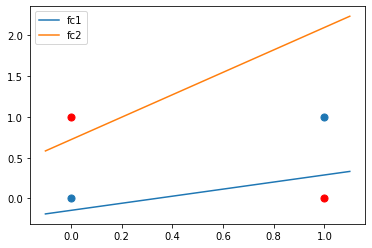

In [18]:
import matplotlib.pyplot as plt

model_weights = model_params[0].data.numpy()
model_bias = model_params[1].data.numpy()

plt.scatter(x.numpy()[[0,-1], 0], x.numpy()[[0, -1], 1], s=50)
plt.scatter(x.numpy()[[1,2], 0], x.numpy()[[1, 2], 1], c='red', s=50)

x_1 = np.arange(-0.1, 1.1, 0.1)
y_1 = ((x_1 * model_weights[0,0]) + model_bias[0]) / (-model_weights[0,1])
plt.plot(x_1, y_1)

x_2 = np.arange(-0.1, 1.1, 0.1)
y_2 = ((x_2 * model_weights[1,0]) + model_bias[1]) / (-model_weights[1,1])
plt.plot(x_2, y_2)
plt.legend(["fc1", "fc2"])
plt.show()